# Reusable Template — Discriminant Analysis Classification Project

Copy this notebook as a starting point for any new tabular classification project using LDA/QDA
(or Logistic Regression as a baseline). Edit the **CONFIG** cell first, then run top to bottom.
Cells that don't need edits are marked `# no edits needed`.


## 0. Config — edit this cell for your project

In [1]:
# ============================================================
# CONFIG — the only cell you should need to touch to get started
# ============================================================

DATA_PATH = None          # e.g. "data/my_data.csv" — set to None to use the built-in demo dataset
TARGET_COL = "target"     # name of the column you want to predict
NUMERIC_COLS = []         # continuous features to scale, e.g. ["age", "income"]
CATEGORICAL_COLS = []     # columns to one-hot encode, e.g. ["region"]
TEST_SIZE = 0.25
RANDOM_STATE = 42
CV_FOLDS = 5
PRIMARY_METRIC = "accuracy"   # for binary problems consider "roc_auc"; multi-class use "accuracy" or "f1_macro"


## 1. Imports (no edits needed)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, classification_report)

np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")


## 2. Load data
If `DATA_PATH` is `None`, falls back to the Iris dataset so the template is runnable out of the box.

In [3]:
if DATA_PATH is None:
    from sklearn.datasets import load_iris
    iris = load_iris()
    df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
    df['target'] = iris.target
    NUMERIC_COLS = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
    CATEGORICAL_COLS = []
    TARGET_COL = 'target'
    print("DATA_PATH not set -- using the built-in Iris demo dataset.")
else:
    df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()


DATA_PATH not set -- using the built-in Iris demo dataset.
(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Exploratory checks (no edits needed, but review the output)

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Class balance:")
print(df[TARGET_COL].value_counts(normalize=True).round(3))


Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64

Class balance:
target
0    0.333
1    0.333
2    0.333
Name: proportion, dtype: float64


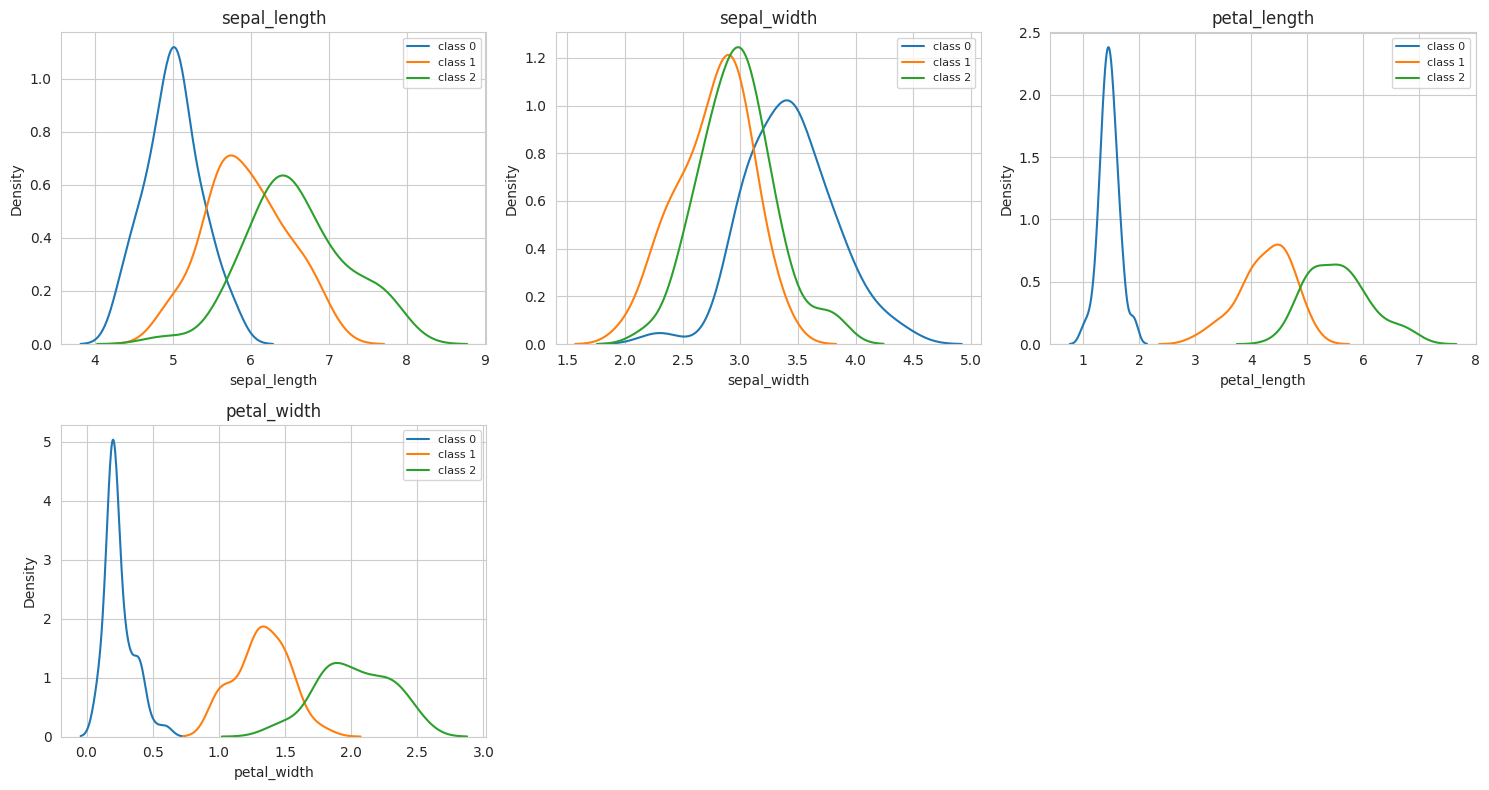

In [5]:
# Distribution of each numeric feature by class -- eyeball for rough normality / equal spread
n_cols = len(NUMERIC_COLS)
if n_cols > 0:
    ncols_grid = min(3, n_cols)
    nrows_grid = int(np.ceil(n_cols / ncols_grid))
    fig, axes = plt.subplots(nrows_grid, ncols_grid, figsize=(5 * ncols_grid, 4 * nrows_grid))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(NUMERIC_COLS):
        for cls in sorted(df[TARGET_COL].unique()):
            sns.kdeplot(df.loc[df[TARGET_COL] == cls, col], ax=axes[i], label=f"class {cls}")
        axes[i].set_title(col)
        axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


In [6]:
# Equal-covariance sanity check across the first two classes present (extend/adapt for >2 classes)
def covariance_similarity(df, features, target, classes):
    covs = [df.loc[df[target] == c, features].cov().values for c in classes]
    diff = np.linalg.norm(covs[0] - covs[1], ord='fro')
    avg = np.mean([np.linalg.norm(c, ord='fro') for c in covs])
    return diff / avg

classes_present = sorted(df[TARGET_COL].unique())
if len(NUMERIC_COLS) > 0 and len(classes_present) >= 2:
    sim = covariance_similarity(df, NUMERIC_COLS, TARGET_COL, classes_present[:2])
    print(f"Relative covariance difference between class {classes_present[0]} and {classes_present[1]}: {sim:.3f}")
    print("(Well under ~0.3-0.4 supports LDA's equal-covariance assumption; higher suggests trying QDA.)")


Relative covariance difference between class 0 and 1: 1.017
(Well under ~0.3-0.4 supports LDA's equal-covariance assumption; higher suggests trying QDA.)


## 4. Preprocess (no edits needed if CONFIG is correct)

In [7]:
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL]

if CATEGORICAL_COLS:
    X = pd.get_dummies(X, columns=CATEGORICAL_COLS)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

if NUMERIC_COLS:
    ct = ColumnTransformer([('scale', StandardScaler(), NUMERIC_COLS)], remainder='passthrough')
    X_train_sc = ct.fit_transform(X_train)
    X_test_sc = ct.transform(X_test)   # fit on train only -- avoids leakage
else:
    X_train_sc, X_test_sc = X_train.values, X_test.values

print("Train shape:", X_train_sc.shape, " Test shape:", X_test_sc.shape)


Train shape: (112, 4)  Test shape: (38, 4)


## 5. Fit candidate models (no edits needed)

In [8]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
}

fitted = {}
for name, model in candidates.items():
    model.fit(X_train_sc, y_train)
    fitted[name] = model


## 6. Evaluate and compare (no edits needed)

In [9]:
results = []
for name, model in fitted.items():
    y_pred = model.predict(X_test_sc)
    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
    }
    if len(classes_present) == 2:
        row["precision"] = precision_score(y_test, y_pred)
        row["recall"] = recall_score(y_test, y_pred)
        row["f1"] = f1_score(y_test, y_pred)
        if hasattr(model, "predict_proba"):
            row["roc_auc"] = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1])
    else:
        row["f1_macro"] = f1_score(y_test, y_pred, average="macro")
    results.append(row)

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,accuracy,f1_macro
model,,
Logistic Regression,0.9211,0.923
LDA,1.0000,1.000
QDA,1.0000,1.000


Best model by 'accuracy': LDA


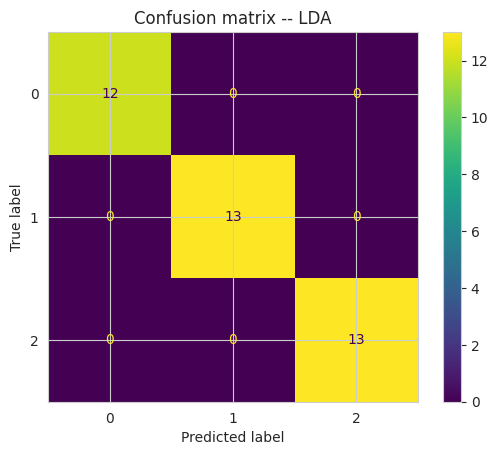

In [10]:
best_name = results_df[PRIMARY_METRIC].idxmax() if PRIMARY_METRIC in results_df.columns else results_df['accuracy'].idxmax()
best_model = fitted[best_name]
print(f"Best model by '{PRIMARY_METRIC}': {best_name}")

ConfusionMatrixDisplay(confusion_matrix(y_test, best_model.predict(X_test_sc))).plot()
plt.title(f"Confusion matrix -- {best_name}")
plt.show()


## 7. Cross-validate the best model (no edits needed)

In [11]:
if NUMERIC_COLS:
    ct_full = ColumnTransformer([('scale', StandardScaler(), NUMERIC_COLS)], remainder='passthrough')
    X_full_sc = ct_full.fit_transform(X)
else:
    X_full_sc = X.values

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = PRIMARY_METRIC if len(classes_present) > 2 and PRIMARY_METRIC == "roc_auc" else \
          (PRIMARY_METRIC if PRIMARY_METRIC in ("accuracy", "f1_macro") else "roc_auc" if len(classes_present) == 2 else "accuracy")

cv_scores = cross_val_score(type(best_model)(), X_full_sc, y, cv=cv, scoring=scoring)
print(f"{best_name} {CV_FOLDS}-fold {scoring}: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")


LDA 5-fold accuracy: 0.973 +/- 0.039


## 8. (Optional) 2D decision-boundary visualization
Only meaningful if you pick exactly two features. Set `feat_x` / `feat_y` below.

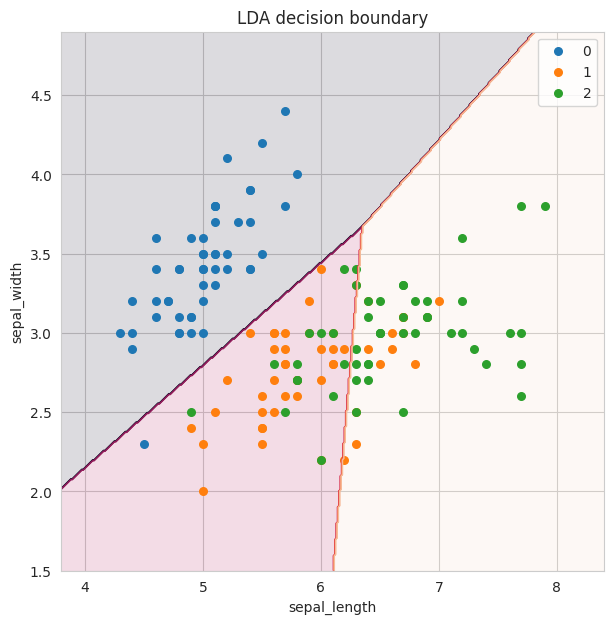

In [12]:
feat_x, feat_y = (NUMERIC_COLS[0], NUMERIC_COLS[1]) if len(NUMERIC_COLS) >= 2 else (None, None)

if feat_x and feat_y:
    X2 = df[[feat_x, feat_y]].values
    y2 = df[TARGET_COL].values
    model_2d = type(best_model)()
    model_2d.fit(X2, y2)

    x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
    y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.contourf(xx, yy, Z, alpha=0.15)
    ax.contour(xx, yy, Z, linewidths=1)
    for cls in sorted(np.unique(y2)):
        pts = X2[y2 == cls]
        ax.scatter(pts[:, 0], pts[:, 1], s=30, label=str(cls))
    ax.set_xlabel(feat_x); ax.set_ylabel(feat_y); ax.legend()
    ax.set_title(f"{best_name} decision boundary")
    plt.show()
else:
    print("Set NUMERIC_COLS with at least 2 entries to enable this visualization.")


## 9. Notes for adapting this template
- If `QuadraticDiscriminantAnalysis` throws a **collinear/singular covariance** warning, either
  drop redundant features, use `reg_param > 0`, or fall back to LDA.
- For **more than 2 classes**, `roc_auc_score` needs `multi_class='ovr'` and full probability
  arrays — swap the scoring call accordingly if you need it.
- If your target is **imbalanced**, look at `precision`, `recall`, and `roc_auc`/`f1_macro`
  more than raw `accuracy`, and consider passing explicit `priors=[...]` to `LinearDiscriminantAnalysis`/`QuadraticDiscriminantAnalysis`.
- For **high-dimensional data** (many features relative to sample size), try
  `LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')` instead of the default solver.
